# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Micaiah

**Date:** 2026-09-08

In [2]:
# Your Phase 1 solution to the problem goes here.


# 1. Load the `./data/ForeignGifts_edu.csv` dataset.

import numpy as np
import pandas as pd
from pathlib import Path # object-oriented file path handling
import matplotlib.pyplot as plt

DATA_DIR = Path("data") # define a variable for the data directory

df = pd.read_csv(DATA_DIR / "ForeignGifts_edu.csv") # load the .csv

df.head() # look at the df

# transform to floating point 64
# df["Foreign Gift Amount"] = pd.to_numeric(df["Foreign Gift Amount"])

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


<function matplotlib.pyplot.show(close=None, block=None)>

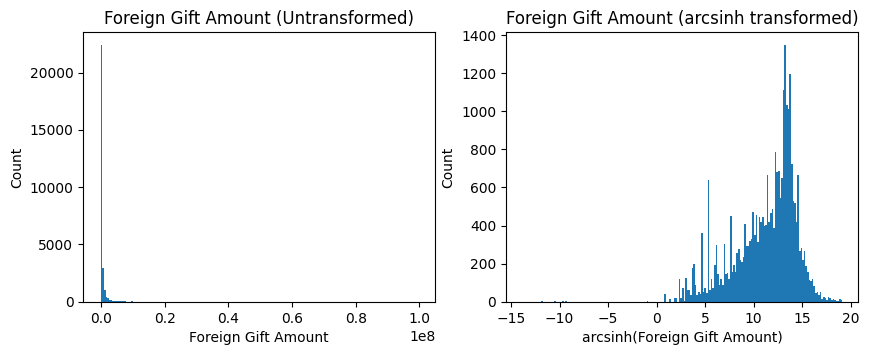

In [8]:
# 2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.


# Make an untransformed histogram
fig, axes = plt.subplots(1, 2, figsize = (10, 3.5))
df["Foreign Gift Amount"].hist(bins = 200, grid = False, ax = axes[0])
axes[0].set(title = "Foreign Gift Amount (Untransformed)", xlabel = "Foreign Gift Amount", ylabel = "Count")

# Make an arcsinh transformed histogram
df["Foreign Gift Amount_arcsinh"] = np.arcsinh(df["Foreign Gift Amount"])
df["Foreign Gift Amount_arcsinh"].hist(bins = 200, grid = False, ax = axes[1])
axes[1].set(title = "Foreign Gift Amount (arcsinh transformed)", xlabel = "arcsinh(Foreign Gift Amount)", ylabel = "Count")

plt.show

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

proportions of each gift type:
61.21% are contracts
38.75% are monetary
0.04% are real estate


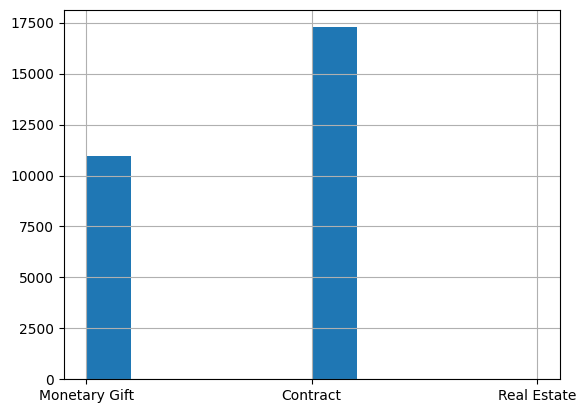

In [14]:
# 3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
df["Gift Type"].hist()
print(df["Gift Type"].value_counts())

# 17274 + 10936 + 11 = 28221 total gifts
# 61.21% are contracts
# 38.75% are monetary
# 0.04% are real estate
print("\nproportions of each gift type:\n61.21% are contracts\n38.75% are monetary\n0.04% are real estate")

c:\Users\micai\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<bound method Figure.set_tight_layout of <Figure size 2000x500 with 4 Axes>>

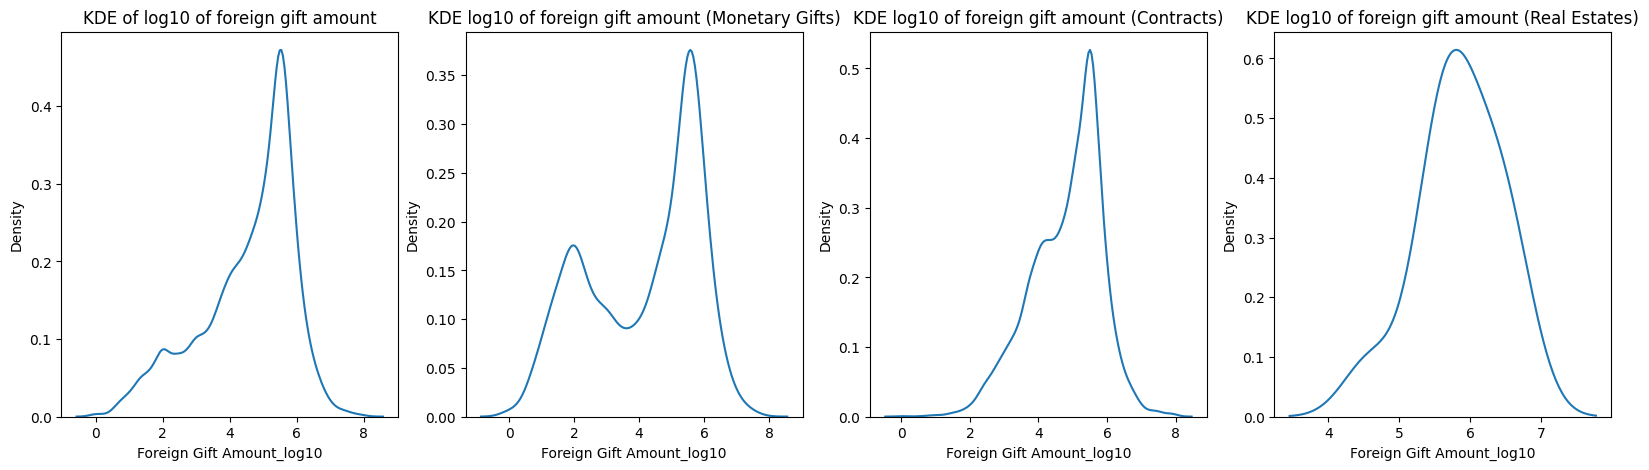

In [ ]:
# 4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
import seaborn as sns


# axes for the plots to go on
fig, axes = plt.subplots(1, 4, figsize = (20, 5))


df["Foreign Gift Amount_log10"] = np.log10(df["Foreign Gift Amount"])

# KDE plot of the log10 of the foreign gift amount
sns.kdeplot(x=df["Foreign Gift Amount_log10"], bw_method="silverman", label = "Kernel Density Estimate", ax=axes[0])
axes[0].set(title = "KDE of log10 of foreign gift amount" )

# KDE plot of the log10 of the foreign gift amount conditional on gift type
# loop iterates through
axes_index = 1
for gift_type in df["Gift Type"].unique():
    df_subset = df[df["Gift Type"] == gift_type]
    sns.kdeplot(x=df_subset["Foreign Gift Amount_log10"], bw_method="silverman", label = "Kernel Density Estimate", ax=axes[axes_index])
    axes[axes_index].set(title = f"KDE log10 of foreign gift amount ({gift_type})")
    axes_index+=1


# I note that there appears to be a somewhat bimodal distribution in the overall KDE which is more clearly visible in the monetary gifts category.The contracts 
# category also has a bump which may indicate a slight bimodality (it looks like  a much smaller gaussian distribution overlaid at that point than in the
# monetary gifts category which looks like two pretty seperated gaussian distributions). Some of the artifacts visible in the overall category are visible as
# structures in the subcategories. Each one also appears to peak around log_10(amount) ~= 6, which is $1E6. 
    

    

In [ ]:
# 5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

print(f"top 15 countires in terms of number of gifts given:\n{df["Country of Giftor"].value_counts().sort_values(ascending=False).head(15)}")

# top 15 countires in terms of number of gifts given:
# Country of Giftor
# ENGLAND            3655
# CHINA              2461
# CANADA             2344
# JAPAN              1896
# SWITZERLAND        1676
# SAUDI ARABIA       1610
# FRANCE             1437
# GERMANY            1394
# HONG KONG          1080
# SOUTH KOREA         811
# QATAR               693
# THE NETHERLANDS     512
# KOREA               452
# INDIA               434
# TAIWAN              381

# print the top 15 of the countries by the amount given (I spent way too long figuring out how to do this in a single line)
print(f"top 15 countires in terms of number of the amount given:\n{df.groupby(["Country of Giftor"], as_index=False).max().sort_values(by="Foreign Gift Amount", ascending = False)[["Country of Giftor", "Foreign Gift Amount"]].head(15)}")

# top 15 countires in terms of number of the amount given:
#         Country of Giftor  Foreign Gift Amount
# 6               AUSTRALIA             99999999
# 114                 QATAR             99999999
# 15                BERMUDA             75000000
# 136              THAILAND             67700000
# 26                 CANADA             48842186
# 58              HONG KONG             47670277
# 93                 MONACO             47600000
# 144  UNITED ARAB EMIRATES             43021197
# 118          SAUDI ARABIA             43000000
# 122             SINGAPORE             40000000
# 64                   IRAQ             39108635
# 61                  INDIA             38000000
# 30                  CHINA             35000000
# 43                ENGLAND             33880638
# 49                GERMANY             33044704




top 15 countires in terms of number of gifts given:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64
top 15 countires in terms of number of the amount given:
        Country of Giftor  Foreign Gift Amount
6               AUSTRALIA             99999999
114                 QATAR             99999999
15                BERMUDA             75000000
136              THAILAND             67700000
26                 CANADA             48842186
58              HONG KONG             47670277
93                 MONACO             47600000
144  UNITED ARAB EMIRATES             43021197
118          SAUDI ARABIA             43000000
122             S

In [ ]:
# 6. Which giftors provide the most money, in total?

print(f"top 15 countires in terms of number of total money given:\n{df.groupby("Country of Giftor")['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)}")

# top 15 countires in terms of number of total money given:
# Country of Giftor
# QATAR                   2706240869
# ENGLAND                 1464906771
# CHINA                   1237952112
# SAUDI ARABIA            1065205930
# BERMUDA                  899593972
# CANADA                   898160656
# HONG KONG                887402529
# JAPAN                    655954776
# SWITZERLAND              619899445
# INDIA                    539556490
# GERMANY                  442475605
# UNITED ARAB EMIRATES     431396357
# FRANCE                   405839396
# SINGAPORE                401157692
# AUSTRALIA                248409202


top 15 countires in terms of number of total money given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name,Foreign Gift Amount_arcsinh,Foreign Gift Amount_log10,total amount by country
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN,13.122363,5.397940,1237952112
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters,13.740048,5.666197,1237952112
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce,15.803140,6.562187,1464906771
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission,7.600903,3.000000,1065205930
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission,11.502390,4.694395,1065205930


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]